Current time: 2:08:29

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 1. (10 point) Betragt den følgende basis for ℝ3 givet ved {-}

Bestem koordinatvektoren [𝑏]𝐸 til 𝑏 =(1,1,−1)mht. ovenstående basis.

Definition 19.6 fra notesættet siger at koordinatvektoren med hensyn til basen kan findes ved at løse det lineær ligningssystem:
$$
A x = b, \qquad A = (v_{0}, v_{1}, v_{2})
$$
Denne ligning vil løses ved at reducere til echelon form og derefter lave back substitution. Echelon form findes gennem en selvlavet funktion, hvorefter back substitution laves med en funktion fra notesættet.

In [2]:
# Selvlavet funktion, som får matricer ned på reduceret echelonform
def reduce_echelon(A, last_col = True):
    # finder dimensioner
    rows, cols = A.shape

    # hvis b er en del af matricen og man ikke vil reducere sidste søjle
    if not last_col:
        cols -= 1

    # holder styr på søjlen til senere
    cur_col = 0

    # reducerer for hver række
    for i in range(rows):

        # hvis der er flere rækker end søjler skipper man de sidste (nulrækker)
        if cur_col >= cols:
            return A
        
        # hvis nuværende søjle har 0 som element skal rækken byttes
        while A[i, cur_col] == 0:

            # finder en række uden 0 til at bytte med
            for j in range(i+1, rows):
                if A[j, cur_col] != 0:
                    A[[i,j], :] = A[[j,i], :]
                    break

            # hvis ingen passer er der ingen pivotelement i søjlen så næste søjle vælges
            # (while løkken kan fortsætte efter der plusses)
            cur_col += 1

            # hvis cur_col overstiger cols i while løkken skal den stadig stoppe
            if cur_col >= cols:
                return A

        # hvis første element i søjlen ikke er 0 kan rækkeoperationer endelig laves
        if A[i, cur_col] != 0:
            A[i] /= A[i, cur_col]   # deler rækken med pivotelementet så den bliver 1
            for j in range(i+1, rows):
                A[j] -= A[j,cur_col] * A[i] # trække række fra andre rækker så de bliver 0 i søjlen
        
        # søjlen bliver ikke incremented automatisk
        cur_col += 1
    return A

In [3]:
# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [4]:
v0 = np.array([3, 2, 1], dtype=float)[:, np.newaxis]
v1 = np.array([1, 0, 2], dtype=float)[:, np.newaxis]
v2 = np.array([1, 1, 0], dtype=float)[:, np.newaxis]
b = np.array([1, 1, -1], dtype=float)[:, np.newaxis]

A = np.column_stack((v0, v1, v2, b))
lign = reduce_echelon(A, last_col=False)
back_subs(lign[:, :3], lign[:, 3])

array([[ 1.],
       [-1.],
       [-1.]])

Svaret er C

## Opgave 2. (10 point) Lad 𝑣0,𝑣1,...,𝑣𝑘−1 være en samling vektorer i ℝ𝑛 med ⟨𝑣𝑖,𝑣𝑗⟩ =0 for alle 𝑖 ≠𝑗. Sæt {-}

Hvad kan vi konkludere med sikkerhed? 

Det vides at B er en samling af ortogonale vektorer. Da grammatricen for ortogonale samlinger vil have en diagonal med $\left< v_{i},v_{i} \right>$ og 0 i alle andre indgange må grammatricen for B være en diagonalmatrix. Svaret er dermed C.

## Opgave 3. (10 point) Lad 𝐴 være matricen {-}

Bestem en basis for nulrummet 𝑁(𝐴)af 𝐴.

In [5]:
A = np.array([[1, 1, 0, -2],
              [1, -1, 2, 0],
              [0, 1, -1, -1]], dtype=float)

echelon = reduce_echelon(A)
echelon

array([[ 1.,  1.,  0., -2.],
       [-0.,  1., -1., -1.],
       [ 0.,  0.,  0.,  0.]])

In [6]:
echelon[0] -= echelon[1]
echelon

array([[ 1.,  0.,  1., -1.],
       [-0.,  1., -1., -1.],
       [ 0.,  0.,  0.,  0.]])

Følgende ligninger opstilles:
$$
\begin{align*}
x_{0} + x_{2} - x_{3} = 0 & \Leftrightarrow x_{0} = x_{3} - x_{2} \\
x_{1} - x_{2} - x_{3} = 0 & \Leftrightarrow x_{1} = x_{2} + x_{3} \\
\end{align*}
$$

Den generelle løsning bliver:
$$
\begin{bmatrix}
x_{0} \\
x_{1} \\
x_{2} \\
x_{3}
\end{bmatrix}
=
\begin{bmatrix}
x_{3} - x_{2} \\
x_{2} + x_{3} \\
x_{2} \\
x_{3}
\end{bmatrix}
=
x_{2}
\begin{bmatrix}
-1 \\
1 \\
1 \\
0
\end{bmatrix}
+
x_{3}
\begin{bmatrix}
1 \\
1 \\
0 \\
1
\end{bmatrix}
$$

Nulrummet N(A) kan da udspændes af følgende vektorer:
$$
N(A) = \text{span} \{
\begin{bmatrix}
-1 \\
1 \\
1 \\
0
\end{bmatrix}
,
\begin{bmatrix}
1 \\
1 \\
0 \\
1
\end{bmatrix}
\}
$$

## Opgave 4. (10 point) Givet vektorer 𝑢 og 𝑣 i ℝ100, med 𝑣 ≠0, beregner den følgende funktion projektionen af 𝑢 langs 𝑣: {-}
```py
def proj_på(v, u):
    return np.vdot(v, u) / np.vdot(v, v) * v
```
Hvor mange flops bruges der i beregningen?

Beregningen består af:
* to række-søjleprodukter  af $2 \cdot 100$ flops ($\left< v,u \right>$ og $\left< v,v \right>$)
* en skalar-skalardivision af $1$ flop ($\frac{\left< v,u \right>}{\left< v,v \right>}$)
* en skalar-vektorprodukt af $100$ flops ($\frac{\left< v,u \right>}{\left< v,v \right>} \cdot v$)

In [7]:
skalar_produkt = 100
rækkesøjle_produkt = 2*100

print("Antallet af flops bliver da", 2*rækkesøjle_produkt + skalar_produkt + 1)

Antallet af flops bliver da 501


Svaret er dermed D.

## Opgave 5. (20 point) Betragt de følgende vektorer i ℝ4: {-}


### (a) Beregn vinklen mellem 𝑢0 og 𝑢2 i grader. {-}

In [8]:
u0 = np.array([1, 1, 1, 1], dtype=float)[:, np.newaxis]
u2 = np.array([1, 1, -1, 1], dtype=float)[:, np.newaxis]

# vinklen mellem vektorerne beregnes ud fra definition 8.5 i notesættet
theta_rad = np.arccos(np.vdot(u0,u2) / (np.linalg.norm(u0, 2) * np.linalg.norm(u2, 2)))
theta_deg = np.rad2deg(theta_rad)
print(f"Vinklen mellem u0 og u2 i grader er: {theta_deg}°")

Vinklen mellem u0 og u2 i grader er: 60.00000000000001°


### (b) Ved brug af rækkeoperationer vis at samlingen 𝑢0,𝑢1,𝑢2 er lineært uafhængig. {-}

In [9]:
u1 = np.array([1, 0, 1, 0], dtype=float)[:, np.newaxis]
V = np.column_stack((u0, u1, u2))

lign = np.column_stack((np.copy(V), np.zeros_like(u0)))
reduce_echelon(lign)

array([[ 1.,  1.,  1.,  0.],
       [-0.,  1., -0., -0.],
       [-0., -0.,  1., -0.],
       [ 0.,  0.,  0.,  0.]])

In [10]:
back_subs(lign[:, :3], lign[:,3])

array([[ 0.],
       [-0.],
       [-0.]])

### (c) Brug Gram-Schmidt processen til at danne en ortonormal samling 𝑣0,𝑣1,𝑣2, der udspænder det samme rum som 𝑢0,𝑢1,𝑢2. {-}

In [11]:
# Fra afsnit 15.3 i notesættet
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

In [12]:
# Gram schmidt kan her bruges da V er lineært uafhængig
# Q vil da være den tilsvarende ortonormale samling som spænder samme rum
q, r = forbedret_gram_schmidt(V)
print(q)

[[ 0.5         0.5         0.70710678]
 [ 0.5        -0.5         0.        ]
 [ 0.5         0.5        -0.70710678]
 [ 0.5        -0.5         0.        ]]


### (d) Forklar hvorfor 𝑣2 er vinkelret på 𝑢0.

Da den nye ortonormale samling er beregnet med gram-schmidt er v0 parralel med u0. Jvf. afsnit 14.1 af notesættet vil alle andre vektorer i samlingen være ortogonale med den forrige vektor, hvilket vil betyde at v2 både vil være ortogonal med v0 og v1 og dermed også u0.

## (d) Forklar hvorfor 𝑣2 er vinkelret på 𝑢0. {-}

Der ønskes et andengradspolynomium 𝑝(𝑥) =𝑏𝑥2 +𝑐𝑥 +𝑑 der går igennem
datapunkterne. Dette svarer til et lineært ligningssystem 𝐴𝑤 =𝑣 med 𝐴 repræ-
senteret af np.vander(x, 3).

### (a) Angiv størrelsen af matricen 𝐴 og vektorerne 𝑤 og 𝑣. Derefter forklar hvordan 𝑤 og 𝑣 i ligningen 𝐴𝑤 =𝑣 svarer til datapunkterne og funktionen 𝑝(𝑥). {-}

In [13]:
x_data = np.array([-0.01, 1.04, 1.31, 1.95, 2.58, 3.28, 3.86])
A = np.vander(x_data, 3)
A.shape

(7, 3)

Koefficientmatricen er A som består af 7 rækker og 3 søjler. Dette betyder at $w$ er en søjlevektor bestående 3 rækker. Resultatet af multiplikationen er da $v$, som er en søjlevektor med 7 rækker.

Som sagt er A koefficientmatricen, da den svarer til x-værdierne i andengradspolynomiet. Vektoren $w$ der ganges på er da variablerne således at:
$$
w =
\begin{bmatrix}
b \\
c \\
d \\
\end{bmatrix}
$$

Den resulterende vektor, $v$, svarer da til y-værdierne eller $p(x)$.

### (b) Brug python til at bestemme singulærværdierne af 𝐴 og brug dette til resultatet til at beregne konditionstallet 𝜅(𝐴).

In [14]:
u, s, vt = np.linalg.svd(A, full_matrices=False)

print("Singulærværdierne er:", s)

# ligning 11.10 i notesættet
kA = s[0] / s[-1]

print("k(A) er:", kA)

Singulærværdierne er: [21.0039193   2.19736347  0.73786421]
k(A) er: 28.465832727545806


### (c) Ved brug af singulærværdidekomponering, bestem i python den mindste kvadraters løsning til systemet 𝐴𝑤 =𝑣 og beregn længde af restvektoren.

In [15]:
# Singulærværdidekomponeringen samt v indsættes i ligning 16.5 fra notesættet
y_data = np.array([0.13, 2.77, 3.12, 2.93, 1.43, -0.01, -1.76])[:, np.newaxis]
w = vt.T @ np.linalg.inv(np.diag(s)) @ u.T @ y_data
w

array([[-0.97600055],
       [ 3.14107906],
       [ 0.36917871]])

In [16]:
# Restvektoren beregnes som vist i afsnit 16.1 i notesættet
r = y_data - A @ w

# længden af vektoren svarer til 2-normen
np.linalg.norm(r, 2)

0.7824296410553815

### (d) Brug python til at lave en plot med datapunkterne og det andengradspolynomium bestemt af din løsning til del (c).

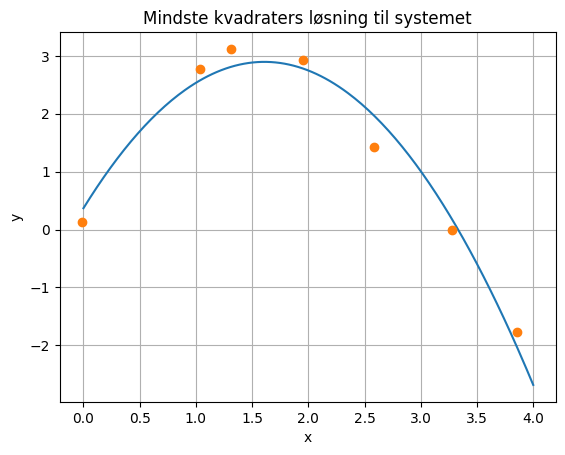

In [17]:
x = np.linspace(0, 4, 200)
px = w[0]*x**2 + w[1]*x + w[2]

fig, ax = plt.subplots()
ax.plot(x, px)
ax.plot(x_data, y_data, "o")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Mindste kvadraters løsning til systemet')
ax.grid()

## Opgave 7. (20 point) Lad 𝐴 være matricen


### (a) Uden brug af python eller lignende, vis at 𝜆0 =5 er en egenværdi for 𝐴 og bestem en tilhørende egenvektor 𝑣0.

$$
\begin{bmatrix}
5 & 0 & 0  \\
1 & 1 & 1  \\
2 & 3 & -1 \\
\end{bmatrix}
$$

Det karakteristiske polynomium sættes op som vist i afsnit 21.5 af notesættet.
\begin{align*}
\text{det}(A - \lambda I_{3}) & = \text{det}\left( \begin{bmatrix}
5 - \lambda & 0 & 0 \\
1 & 1 - \lambda & 1 \\
2 & 3 & -1 - \lambda
\end{bmatrix} \right)\\
 & = (5 - \lambda) \text{det} \left(\begin{bmatrix}
1 - \lambda & 1 \\
3 & -1 - \lambda
\end{bmatrix}\right) - 0 \, \text{det} \left(\begin{bmatrix}
1 & 1 \\
2 & -1 - \lambda
\end{bmatrix}\right) + 0 \, \text{det} \left(\begin{bmatrix}
1 & 1 - \lambda \\
2 & 3
\end{bmatrix}\right)\\
 & = (5 - \lambda) ((1 - \lambda) (-1 - \lambda) - 1 \cdot 3) \\
 & = (5 - \lambda) (-1 - \lambda + \lambda + \lambda^{2} - 3) \\
 & = (5 - \lambda) (-4 + \lambda^{2}) \\
 & = - \lambda^{3} + 5 \lambda^{2} + 4 \lambda - 20 \\
\end{align*}

Hvis $\lambda_{0}$ er en egenværdi for $A$ skal det karakteristiske polynomium give 0, når den indsættes.
$$
-5^{3} + 5 \cdot 5^{2} + 4 \cdot 5 - 20 = -5^{3} + 5^{3} + 20 - 20 = 0
$$
Da udtrykket passer må $\lambda_{0}=5$ være en egenværdi for $A$. 

Den tilhørende egenvektor bestemmes ved at løse ligningen $(A - \lambda_{0} I_{3}) v_{0} = 0$. Dette kan gøres gennem rækkeoperationer.
$$
A - \lambda_{0} I_{3} =
\begin{bmatrix}
5 - 5 & 0 & 0  \\
1 & 1 - 5 & 1  \\
2 & 3 & -1 - 5 \\
\end{bmatrix}
=
\begin{bmatrix}
0 & 0 & 0  \\
1 & -4 & 1  \\
2 & 3 & -6 \\
\end{bmatrix}
\sim_{R_{2} \to R_{2} - 2R_{1}}
\begin{bmatrix}
0 & 0 & 0  \\
1 & -4 & 1  \\
0 & 11 & -8 \\
\end{bmatrix}
$$
Følgende ligninger skal løses
$$
\begin{cases}
x_{0} - 4y_{0} + z_{0} = 0 \\
0 + 11y_{0} - 8z_{0} = 0
\end{cases}
$$
Den nederste ligning kan løses med $y_{0} = \frac{1}{11}$ og $z_{0} = \frac{1}{8}$. Disse værdier kan da indsættes i den øverste ligning for at finde $x_{0}$.
\begin{align*}
x_{0} - 4 \cdot \frac{1}{11} + \frac{1}{8} & = 0 \\
x_{0} & = 4 \cdot \frac{8}{88} - \frac{11}{88} \\
x_{0} & = \frac{32}{88} - \frac{11}{88} \\
x_{0} & = \frac{21}{88}
\end{align*}
En løsning kan da være
$$
v_{0} = 
\begin{bmatrix}
21/88 \\
1/11 \\
1/8
\end{bmatrix}
$$

### (b) Uden brug af python eller lignende, vis at vektoren {-}
$$
v_{1} =
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}
$$
er en egenvektor for 𝐴 og bestem dens tilhørende egenværdi 𝜆1.

Ifølge definition 21.1 skal der være en $\lambda$ der opfylder $Av_{1} = \lambda_{1} v_{1}$ før $v_{1}$ kan være en egenvektor for $A$. Når venstre siden udregnes fås følgende:
$$
Av_{1} =
\begin{bmatrix}
5 & 0 & 0 \\
1 & 1 & 1 \\
2 & 3 & -1
\end{bmatrix}
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
0 \\
2 \\
2
\end{bmatrix}
$$
Dette kan reproduceres på højre side ved at sætte $\lambda_{1}=2$
$$
\lambda_{1}v_{1} =
2
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
0 \\
2 \\
2
\end{bmatrix}
$$
$v_{1}$ er da en egenvektor for $A$ til egenværdien $\lambda_{1} = 2$.

### (c) I python brug inverspotensmetoden til at bestemme den sidste egenværdi 𝜆2 af 𝐴 og en tilhørende egenvektor 𝑣2 af længde 1.

In [25]:
# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

# Fra afsnit 17.3 i notesættet
def house(x):
    u = x / np.linalg.norm(x)
    eps = +1 if u[0, 0] >= 0 else -1
    s = 1 + np.abs(u[0, 0])
    v = (eps / s) * u
    v[0, 0] = 1
    return v, s

def householder_qr_data(a):
    data = np.copy(a)
    _, k = a.shape
    s = np.empty(k)
    for j in range(k):
        v, s[j] = house(data[j:, [j]])
        data[j:, j:] -= (s[j] * v) @ (v.T @ data[j:, j:])
        data[j+1:, [j]] = v[1:]
    return data, s

def householder_qr(a):
    data, s = householder_qr_data(a)
    n, k = a.shape
    r = np.triu(data[:k, :k])
    q = np.eye(n, k)
    for j in reversed(range(k)):
        x = data[j+1:, [j]]
        v = np.vstack([[1], x])
        q[j:, j:] -= (s[j] * v) @ (v.T @ q[j:, j:])
    return q, r

# Fra eksempel 24.10 i notesættet 
# mu er ændret til a for at få matricen som input
def inv_potens_skridt(q, r, w, a):
    v = back_subs(r, q.T @ w)
    v /= np.linalg.norm(v)
    lambda_ny = np.vdot(v, a @ v)
    return lambda_ny, v

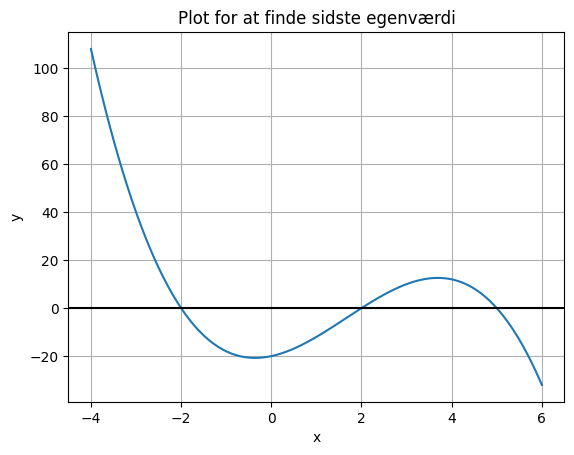

In [26]:
# Den sidste egenværdi estimeres først ved at aflæse polynomiets skæring på x-aksen
x = np.linspace(-4, 6, 200)
y = -x**3 + 5 * x**2 + 4 * x - 20

fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Plot for at finde sidste egenværdi')
ax.grid()
ax.axhline(0, color='black')

In [29]:
# Følger eksempel 24.10 i notesættet
A = np.array([[5, 0, 0],
              [1, 1, 1],
              [2, 3, -1]], dtype=float)

mu = -2.0

rng = np.random.default_rng()

m, _ = A.shape

b = A - mu * np.eye(m)
q, r = householder_qr(b)

w = rng.standard_normal((m, 1))
w /= np.linalg.norm(w)

n = 20
lambda_out = np.empty(n)

for i in range(n):
    lambda_out[i], w = inv_potens_skridt(q, r, w, A)

print(f"Den sidste egenværdi er {lambda_out[-1]} \nog den tilhørende egenvektor er \n{w}")

Den sidste egenværdi er -1.9999999999999998 
og den tilhørende egenvektor er 
[[-1.12209787e-18]
 [-3.16227766e-01]
 [ 9.48683298e-01]]
